In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, shapiro, ttest_rel

In [2]:
def load_results(path):
    df = pd.read_csv(path)

    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    for col in df.columns:
        if col.endswith("_all"):
            df[col] = (
                df[col]
                .str.replace('[', '')
                .str.replace(']', '')
                .apply(lambda x: [float(v) for v in x.split()])
            )
    return df

def to_long_feat(df, feat_label, metric="F1_macro"):
    rows = []

    for _, row in df.iterrows():
        model = row["Model"]
        scores = row[f"CV_{metric}_all"]

        for s in scores:
            rows.append({
                "FeatureEngineering": feat_label,
                "Model": model,
                metric: s
            })

    return pd.DataFrame(rows)

## TweetEmotionsPTBR

### Feat BoW

In [3]:
paths = {
    "WITHOUT_FEATURE_ENGINEERING": "../../data/out/baseline/baseline_03_TweetEmotionsPTBR_BoW.csv",
    "WITH_FEATURE_ENGINEERING": "../../data/out/feat/feat_03_TweetEmotionsPTBR_BoW.csv"
}

dfs = []

for name, path in paths.items():
    df = load_results(path)
    dfs.append(to_long_feat(df, name))

df_long = pd.concat(dfs, ignore_index=True)

df_pair = (
    df_long
    .groupby("FeatureEngineering")
    .head(df_long.groupby("FeatureEngineering").size().min())
    .reset_index(drop=True)
)

scores_without = (
    df_pair[df_pair["FeatureEngineering"] == "WITHOUT_FEATURE_ENGINEERING"]["F1_macro"]
    .to_numpy()
)

scores_with = (
    df_pair[df_pair["FeatureEngineering"] == "WITH_FEATURE_ENGINEERING"]["F1_macro"]
    .to_numpy()
)

stat, p = wilcoxon(scores_without, scores_with)

n = len(scores_without)
mean_w = n * (n + 1) / 4
std_w = np.sqrt(n * (n + 1) * (2*n + 1) / 24)

z = (stat - mean_w) / std_w
r = abs(z) / np.sqrt(n)

print(f"Wilcoxon stat = {stat:.4f}")
print(f"p-value = {p:.6f}")
print(f"Z = {z:.4f}")
print(f"Effect size (r) = {r:.4f}")

Wilcoxon stat = 3267.0000
p-value = 0.000011
Z = -4.4945
Effect size (r) = 0.3670


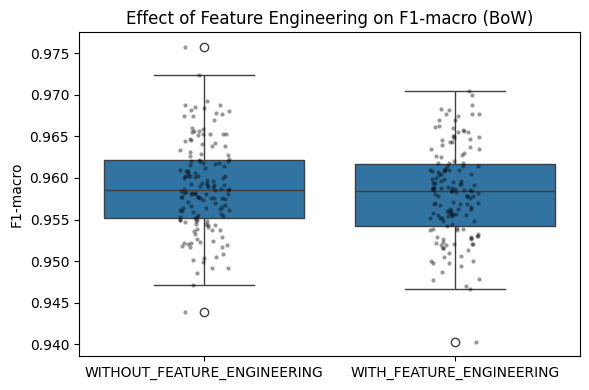

In [6]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_long,
    x="FeatureEngineering",
    y="F1_macro"
)

sns.stripplot(
    data=df_long,
    x="FeatureEngineering",
    y="F1_macro",
    color="black",
    alpha=0.4,
    size=3
)

plt.title("Effect of Feature Engineering on F1-macro (BoW)")
plt.xlabel("")
plt.ylabel("F1-macro")
plt.tight_layout()
plt.show()

### Feat TFIDF

In [7]:
paths = {
    "WITHOUT_FEATURE_ENGINEERING": "../../data/out/baseline/baseline_03_TweetEmotionsPTBR_TFIDF.csv",
    "WITH_FEATURE_ENGINEERING": "../../data/out/feat/feat_03_TweetEmotionsPTBR_TFIDF.csv"
}

dfs = []

for name, path in paths.items():
    df = load_results(path)
    dfs.append(to_long_feat(df, name))

df_long = pd.concat(dfs, ignore_index=True)

df_pair = (
    df_long
    .groupby("FeatureEngineering")
    .head(df_long.groupby("FeatureEngineering").size().min())
    .reset_index(drop=True)
)

scores_without = (
    df_pair[df_pair["FeatureEngineering"] == "WITHOUT_FEATURE_ENGINEERING"]["F1_macro"]
    .to_numpy()
)

scores_with = (
    df_pair[df_pair["FeatureEngineering"] == "WITH_FEATURE_ENGINEERING"]["F1_macro"]
    .to_numpy()
)

stat, p = wilcoxon(scores_without, scores_with)

n = len(scores_without)
mean_w = n * (n + 1) / 4
std_w = np.sqrt(n * (n + 1) * (2*n + 1) / 24)

z = (stat - mean_w) / std_w
r = abs(z) / np.sqrt(n)

print(f"Wilcoxon stat = {stat:.4f}")
print(f"p-value = {p:.6f}")
print(f"Z = {z:.4f}")
print(f"Effect size (r) = {r:.4f}")

Wilcoxon stat = 3250.0000
p-value = 0.000006
Z = -4.5264
Effect size (r) = 0.3696


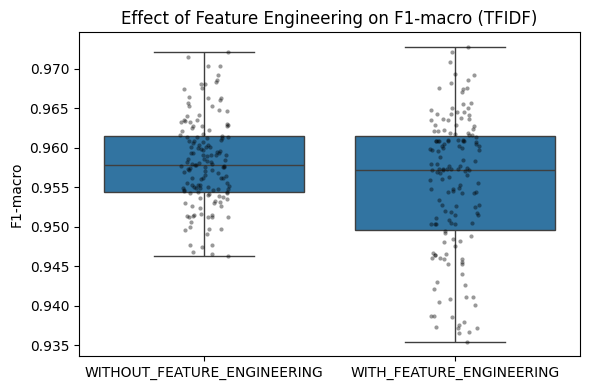

In [8]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_long,
    x="FeatureEngineering",
    y="F1_macro"
)

sns.stripplot(
    data=df_long,
    x="FeatureEngineering",
    y="F1_macro",
    color="black",
    alpha=0.4,
    size=3
)

plt.title("Effect of Feature Engineering on F1-macro (TFIDF)")
plt.xlabel("")
plt.ylabel("F1-macro")
plt.tight_layout()
plt.show()

## GoEmotions

### Feat BoW

In [6]:
paths = {
    "WITHOUT_FEATURE_ENGINEERING": "../../data/out/baseline/baseline_05_GoEmotions_BoW_PT.csv",
    "WITH_FEATURE_ENGINEERING": "../../data/out/feat/feat_05_GoEmotions_BoW.csv"
}

dfs = []

for name, path in paths.items():
    df = load_results(path)
    dfs.append(to_long_feat(df, name))

dfs = [df[df["Model"] != "RandomForest"] for df in dfs]

df_long = pd.concat(dfs, ignore_index=True)

df_pair = (
    df_long
    .groupby("FeatureEngineering")
    .head(df_long.groupby("FeatureEngineering").size().min())
    .reset_index(drop=True)
)

scores_without = (
    df_pair[df_pair["FeatureEngineering"] == "WITHOUT_FEATURE_ENGINEERING"]["F1_macro"]
    .to_numpy()
)

scores_with = (
    df_pair[df_pair["FeatureEngineering"] == "WITH_FEATURE_ENGINEERING"]["F1_macro"]
    .to_numpy()
)

stat, p = wilcoxon(scores_without, scores_with)

n = len(scores_without)
mean_w = n * (n + 1) / 4
std_w = np.sqrt(n * (n + 1) * (2*n + 1) / 24)

z = (stat - mean_w) / std_w
r = abs(z) / np.sqrt(n)

print(f"Wilcoxon stat = {stat:.4f}")
print(f"p-value = {p:.6f}")
print(f"Z = {z:.4f}")
print(f"Effect size (r) = {r:.4f}")

Wilcoxon stat = 2282.0000
p-value = 0.000415
Z = -3.5302
Effect size (r) = 0.3223


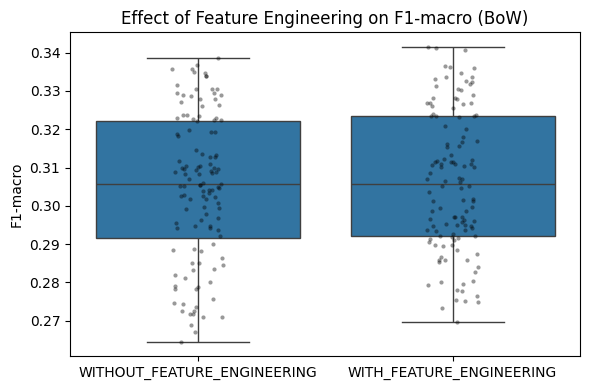

In [7]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_long,
    x="FeatureEngineering",
    y="F1_macro"
)

sns.stripplot(
    data=df_long,
    x="FeatureEngineering",
    y="F1_macro",
    color="black",
    alpha=0.4,
    size=3
)

plt.title("Effect of Feature Engineering on F1-macro (BoW)")
plt.xlabel("")
plt.ylabel("F1-macro")
plt.tight_layout()
plt.show()

In [9]:
shapiro(scores_with - scores_without)

ShapiroResult(statistic=np.float64(0.9179698045999088), pvalue=np.float64(1.8390546356631584e-06))

In [12]:
t_stat, p_t = ttest_rel(scores_without, scores_with)

print(f"t-stat = {t_stat:.4f}")
print(f"p-value = {p_t:.6f}")

t-stat = -2.4481
p-value = 0.015819


In [13]:
results = []

for model in df_long["Model"].unique():

    df_m = df_long[df_long["Model"] == model]

    scores_without = df_m[df_m["FeatureEngineering"] == "WITHOUT_FEATURE_ENGINEERING"]["F1_macro"].to_numpy()
    scores_with = df_m[df_m["FeatureEngineering"] == "WITH_FEATURE_ENGINEERING"]["F1_macro"].to_numpy()

    stat, p = wilcoxon(scores_without, scores_with)

    results.append({
        "Model": model,
        "p_value": p,
        "mean_without": np.mean(scores_without),
        "mean_with": np.mean(scores_with)
    })

pd.DataFrame(results)

,Model,p_value,mean_without,mean_with
0,LogisticRegression,5.587935e-09,0.278956,0.285267
1,RidgeClassifier,9.313226e-09,0.309031,0.310893
2,LinearSVC,5.012613e-03,0.328329,0.330193
3,XGBClassifier,2.766320e-03,0.303380,0.298659


### Feat TFIDF

In [14]:
paths = {
    "WITHOUT_FEATURE_ENGINEERING": "../../data/out/baseline/baseline_05_GoEmotions_TFIDF_PT.csv",
    "WITH_FEATURE_ENGINEERING": "../../data/out/feat/feat_05_GoEmotions_TFIDF.csv"
}

dfs = []

for name, path in paths.items():
    df = load_results(path)
    dfs.append(to_long_feat(df, name))

dfs = [df[df["Model"] != "RandomForest"] for df in dfs]

df_long = pd.concat(dfs, ignore_index=True)

df_pair = (
    df_long
    .groupby("FeatureEngineering")
    .head(df_long.groupby("FeatureEngineering").size().min())
    .reset_index(drop=True)
)

scores_without = (
    df_pair[df_pair["FeatureEngineering"] == "WITHOUT_FEATURE_ENGINEERING"]["F1_macro"]
    .to_numpy()
)

scores_with = (
    df_pair[df_pair["FeatureEngineering"] == "WITH_FEATURE_ENGINEERING"]["F1_macro"]
    .to_numpy()
)

stat, p = wilcoxon(scores_without, scores_with)

n = len(scores_without)
mean_w = n * (n + 1) / 4
std_w = np.sqrt(n * (n + 1) * (2*n + 1) / 24)

z = (stat - mean_w) / std_w
r = abs(z) / np.sqrt(n)

print(f"Wilcoxon stat = {stat:.4f}")
print(f"p-value = {p:.6f}")
print(f"Z = {z:.4f}")
print(f"Effect size (r) = {r:.4f}")

Wilcoxon stat = 1138.0000
p-value = 0.000000
Z = -6.5262
Effect size (r) = 0.5958


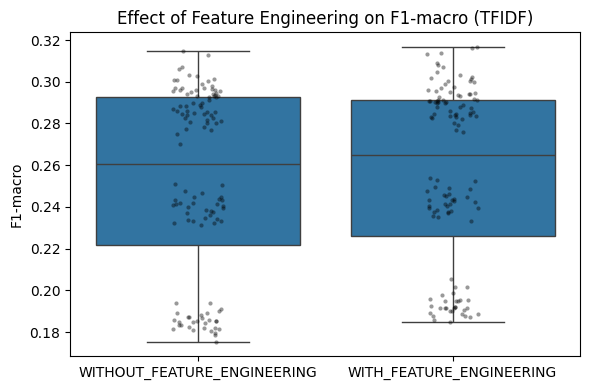

In [15]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_long,
    x="FeatureEngineering",
    y="F1_macro"
)

sns.stripplot(
    data=df_long,
    x="FeatureEngineering",
    y="F1_macro",
    color="black",
    alpha=0.4,
    size=3
)

plt.title("Effect of Feature Engineering on F1-macro (TFIDF)")
plt.xlabel("")
plt.ylabel("F1-macro")
plt.tight_layout()
plt.show()

In [16]:
shapiro(scores_with - scores_without)

ShapiroResult(statistic=np.float64(0.9291550814507267), pvalue=np.float64(8.526128199961017e-06))

In [17]:
t_stat, p_t = ttest_rel(scores_without, scores_with)

print(f"t-stat = {t_stat:.4f}")
print(f"p-value = {p_t:.6f}")

t-stat = -6.7598
p-value = 0.000000


In [18]:
results = []

for model in df_long["Model"].unique():

    df_m = df_long[df_long["Model"] == model]

    scores_without = df_m[df_m["FeatureEngineering"] == "WITHOUT_FEATURE_ENGINEERING"]["F1_macro"].to_numpy()
    scores_with = df_m[df_m["FeatureEngineering"] == "WITH_FEATURE_ENGINEERING"]["F1_macro"].to_numpy()

    stat, p = wilcoxon(scores_without, scores_with)

    results.append({
        "Model": model,
        "p_value": p,
        "mean_without": np.mean(scores_without),
        "mean_with": np.mean(scores_with)
    })

pd.DataFrame(results)

,Model,p_value,mean_without,mean_with
0,LogisticRegression,1.862645e-09,0.184959,0.192704
1,RidgeClassifier,1.862645e-09,0.239815,0.242869
2,LinearSVC,3.855675e-07,0.285566,0.290078
3,XGBClassifier,4.771065e-01,0.296882,0.296051


### Feat BoW SMOTE

In [20]:
paths = {
    "WITHOUT_FEATURE_ENGINEERING": "../../data/out/baseline/baseline_05_GoEmotions_BoW_PT.csv",
    "WITH_FEATURE_ENGINEERING_SMOTE": "../../data/out/feat/feat_05_GoEmotions_BoW_SMOTE.csv"
}

dfs = []

for name, path in paths.items():
    df = load_results(path)
    dfs.append(to_long_feat(df, name))

dfs = [df[df["Model"] != "RandomForest"] for df in dfs]

df_long = pd.concat(dfs, ignore_index=True)

df_pair = (
    df_long
    .groupby("FeatureEngineering")
    .head(df_long.groupby("FeatureEngineering").size().min())
    .reset_index(drop=True)
)

scores_without = (
    df_pair[df_pair["FeatureEngineering"] == "WITHOUT_FEATURE_ENGINEERING"]["F1_macro"]
    .to_numpy()
)

scores_with = (
    df_pair[df_pair["FeatureEngineering"] == "WITH_FEATURE_ENGINEERING_SMOTE"]["F1_macro"]
    .to_numpy()
)

stat, p = wilcoxon(scores_without, scores_with)

n = len(scores_without)
mean_w = n * (n + 1) / 4
std_w = np.sqrt(n * (n + 1) * (2*n + 1) / 24)

z = (stat - mean_w) / std_w
r = abs(z) / np.sqrt(n)

print(f"Wilcoxon stat = {stat:.4f}")
print(f"p-value = {p:.6f}")
print(f"Z = {z:.4f}")
print(f"Effect size (r) = {r:.4f}")

Wilcoxon stat = 0.0000
p-value = 0.000000
Z = -9.5065
Effect size (r) = 0.8678


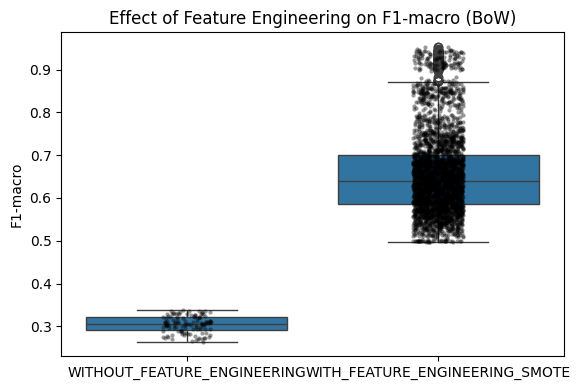

In [21]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_long,
    x="FeatureEngineering",
    y="F1_macro"
)

sns.stripplot(
    data=df_long,
    x="FeatureEngineering",
    y="F1_macro",
    color="black",
    alpha=0.4,
    size=3
)

plt.title("Effect of Feature Engineering on F1-macro (BoW)")
plt.xlabel("")
plt.ylabel("F1-macro")
plt.tight_layout()
plt.show()

In [22]:
shapiro(scores_with - scores_without)

ShapiroResult(statistic=np.float64(0.8373948686549908), pvalue=np.float64(3.5970449868225227e-10))

In [23]:
t_stat, p_t = ttest_rel(scores_without, scores_with)

print(f"t-stat = {t_stat:.4f}")
print(f"p-value = {p_t:.6f}")

t-stat = -44.9386
p-value = 0.000000


### Feat TFIDF SMOTE

In [27]:
paths = {
    "WITHOUT_FEATURE_ENGINEERING": "../../data/out/baseline/baseline_05_GoEmotions_TFIDF_PT.csv",
    "WITH_FEATURE_ENGINEERING_SMOTE": "../../data/out/feat/feat_05_GoEmotions_TFIDF_SMOTE.csv"
}

dfs = []

for name, path in paths.items():
    df = load_results(path)
    dfs.append(to_long_feat(df, name))

dfs = [df[df["Model"] != "RandomForest"] for df in dfs]

df_long = pd.concat(dfs, ignore_index=True)

df_pair = (
    df_long
    .groupby("FeatureEngineering")
    .head(df_long.groupby("FeatureEngineering").size().min())
    .reset_index(drop=True)
)

scores_without = (
    df_pair[df_pair["FeatureEngineering"] == "WITHOUT_FEATURE_ENGINEERING"]["F1_macro"]
    .to_numpy()
)

scores_with = (
    df_pair[df_pair["FeatureEngineering"] == "WITH_FEATURE_ENGINEERING_SMOTE"]["F1_macro"]
    .to_numpy()
)

stat, p = wilcoxon(scores_without, scores_with)

n = len(scores_without)
mean_w = n * (n + 1) / 4
std_w = np.sqrt(n * (n + 1) * (2*n + 1) / 24)

z = (stat - mean_w) / std_w
r = abs(z) / np.sqrt(n)

print(f"Wilcoxon stat = {stat:.4f}")
print(f"p-value = {p:.6f}")
print(f"Z = {z:.4f}")
print(f"Effect size (r) = {r:.4f}")

Wilcoxon stat = 0.0000
p-value = 0.000000
Z = -9.5065
Effect size (r) = 0.8678


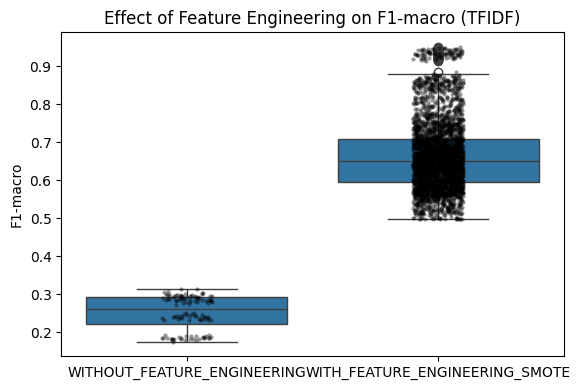

In [28]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_long,
    x="FeatureEngineering",
    y="F1_macro"
)

sns.stripplot(
    data=df_long,
    x="FeatureEngineering",
    y="F1_macro",
    color="black",
    alpha=0.4,
    size=3
)

plt.title("Effect of Feature Engineering on F1-macro (TFIDF)")
plt.xlabel("")
plt.ylabel("F1-macro")
plt.tight_layout()
plt.show()

In [29]:
shapiro(scores_with - scores_without)

ShapiroResult(statistic=np.float64(0.8133322184689451), pvalue=np.float64(4.869464308065043e-11))

In [30]:
t_stat, p_t = ttest_rel(scores_without, scores_with)

print(f"t-stat = {t_stat:.4f}")
print(f"p-value = {p_t:.6f}")

t-stat = -38.4905
p-value = 0.000000


### 1 VS 1

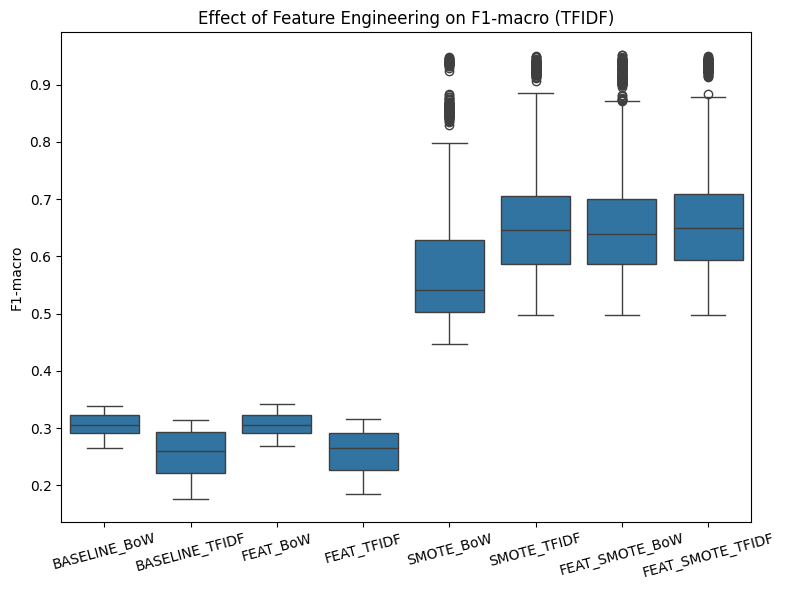

In [42]:
paths = {
    "BASELINE_BoW": "../../data/out/baseline/baseline_05_GoEmotions_BoW_PT.csv",
    "BASELINE_TFIDF": "../../data/out/baseline/baseline_05_GoEmotions_TFIDF_PT.csv",
    "FEAT_BoW": "../../data/out/feat/feat_05_GoEmotions_BoW.csv",
    "FEAT_TFIDF": "../../data/out/feat/feat_05_GoEmotions_TFIDF.csv",
    "SMOTE_BoW": "../../data/out/balanced/balanced_05_GoEmotions_BoW_SMOTE.csv",
    "SMOTE_TFIDF": "../../data/out/balanced/balanced_05_GoEmotions_TFIDF_SMOTE.csv",
    "FEAT_SMOTE_BoW": "../../data/out/feat/feat_05_GoEmotions_BoW_SMOTE.csv",
    "FEAT_SMOTE_TFIDF": "../../data/out/feat/feat_05_GoEmotions_TFIDF_SMOTE.csv"
}

dfs = []

for name, path in paths.items():
    df = load_results(path)
    dfs.append(to_long_feat(df, name))

dfs = [df[df["Model"] != "RandomForest"] for df in dfs]

df_long = pd.concat(dfs, ignore_index=True)

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_long,
    x="FeatureEngineering",
    y="F1_macro"
)

plt.title("Effect of Feature Engineering on F1-macro (TFIDF)")
plt.xlabel("")
plt.xticks(rotation=15) 
plt.ylabel("F1-macro")
plt.tight_layout()
plt.show()

In [ ]:
shapiro(scores_with - scores_without)

ShapiroResult(statistic=np.float64(0.8133322184689451), pvalue=np.float64(4.869464308065043e-11))

In [ ]:
t_stat, p_t = ttest_rel(scores_without, scores_with)

print(f"t-stat = {t_stat:.4f}")
print(f"p-value = {p_t:.6f}")

t-stat = -38.4905
p-value = 0.000000
